In [2]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt

In [3]:
# Load the dataset
df=pd.read_csv('ML.csv')
df

,Batch,User_ID,Score
0,AI_ELITE_7,uid_149,6 / 7
1,AI_ELITE_7,uid_148,6 / 7
2,AI_ELITE_7,uid_147,7 / 7
3,AI_ELITE_7,uid_146,7 / 7
4,AI_ELITE_7,uid_145,4 / 7
...,...,...,...
144,AI_ELITE_4,uid_5,4 / 7
145,AI_ELITE_4,uid_4,4 / 7
146,AI_ELITE_4,uid_3,4 / 7
147,AI_ELITE_4,uid_2,3 / 7


In [4]:
# Basic data exploration
df.head()
df.tail()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Batch        149 non-null    object
 1   User_ID      149 non-null    object
 2      Score     149 non-null    object
dtypes: object(3)
memory usage: 3.6+ KB


,Batch,User_ID,Score
count,149,149,149
unique,3,149,8
top,AI_ELITE_7,uid_149,4 / 7
freq,53,1,40


In [5]:
# Check for missing values
((df.isnull().sum()/len(df)*100).sort_values(ascending=False)).head(10)

Batch          0.0
User_ID        0.0
   Score       0.0
dtype: float64

In [6]:
df.columns

Index(['Batch ', 'User_ID ', '   Score   '], dtype='object')

In [7]:
# Remove leading/trailing whitespace from column names
df.columns = df.columns.str.strip()
df.columns

Index(['Batch', 'User_ID', 'Score'], dtype='object')

### 1. UNIVARIATE ANALYSIS (One column at a time)

#### A) Numerical Univariate

Non-visual

In [8]:
# Final overview
df.describe()

,Batch,User_ID,Score
count,149,149,149
unique,3,149,8
top,AI_ELITE_7,uid_149,4 / 7
freq,53,1,40


visual

In [9]:
# histogram

# use the numeric series already prepared (score_num) or specify the column name via column=
plt.hist(score_num, bins=20, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()


NameError: name 'score_num' is not defined

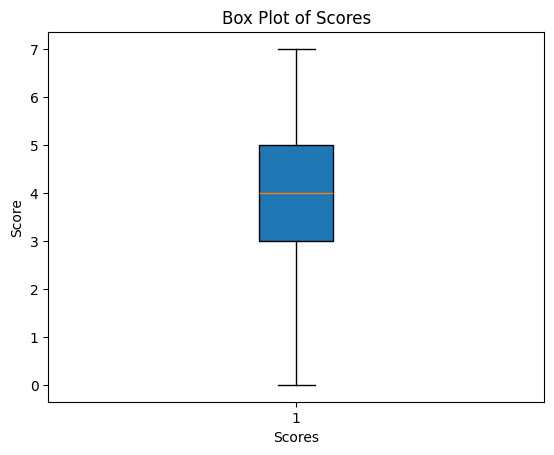

In [ ]:
# box plot
plt.boxplot(score_num, vert=True, patch_artist=True)
plt.ylabel('Score')
plt.xlabel('Scores')
plt.title('Box Plot of Scores')
plt.show()

#### B) Categorical Univariate

##### 🔸Non-visual

In [ ]:
#frequency test

print(df['Score'].value_counts())

#percentage test
print((df['Score'].value_counts(normalize=True)*100).round(2))
#number of unique values
print(df['Score'].nunique())


Score
4 / 7    40
5 / 7    32
3 / 7    24
7 / 7    18
6 / 7    18
2 / 7    12
1 / 7     3
0 / 7     2
Name: count, dtype: int64
Score
4 / 7    26.85
5 / 7    21.48
3 / 7    16.11
7 / 7    12.08
6 / 7    12.08
2 / 7     8.05
1 / 7     2.01
0 / 7     1.34
Name: proportion, dtype: float64
8


##### 🔸Visual

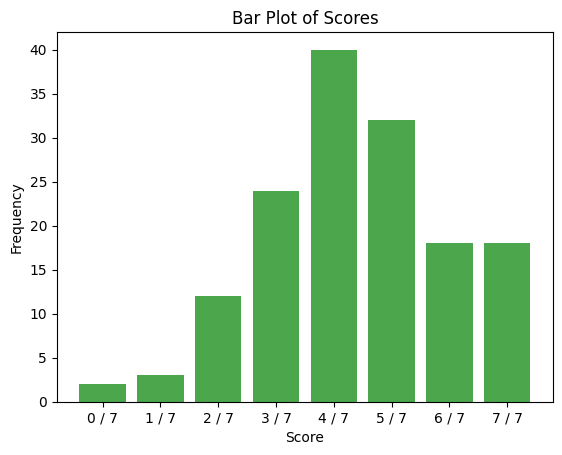

In [ ]:
#bar chart
score_counts = df['Score'].value_counts().sort_index()
plt.bar(score_counts.index, score_counts.values, color='green', alpha=0.7)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Bar Plot of Scores')
plt.show()

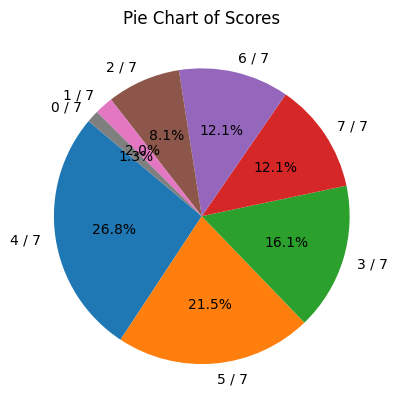

In [ ]:
#   pie chart
score_counts = df['Score'].value_counts()
plt.pie(score_counts, labels=score_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Pie Chart of Scores')
plt.show()

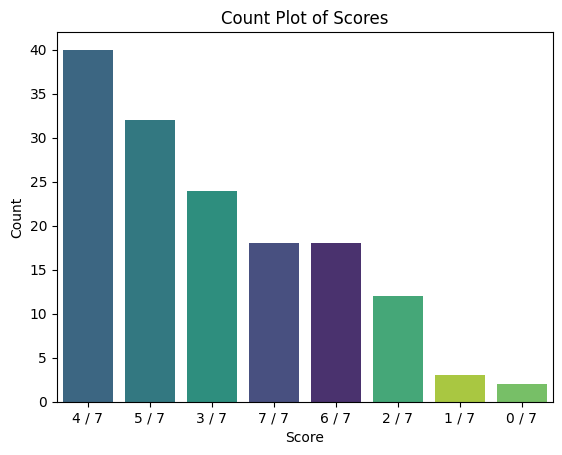

In [ ]:
import seaborn as sns

#count plot
sns.countplot(x='Score',hue='Score',data=df, palette='viridis', order=df['Score'].value_counts().index)
plt.title('Count Plot of Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

### 2. BIVARIATE ANALYSIS (Two columns together)

#### A) Numerical vs Numerical

##### 🔸Non-Visual

In [ ]:
# correlation
# select numeric columns (Score is numeric in df_numeric) to avoid KeyError and non-numeric correlation
df_numeric.select_dtypes(include=[np.number]).corr()



,Score
Score,1.0


In [ ]:
# covariance of numeric columns
# use df_numeric which has numeric 'Score' to avoid converting non-numeric columns
df_numeric.select_dtypes(include=[np.number]).cov()

,Score
Score,2.535099


##### 🔸Visual

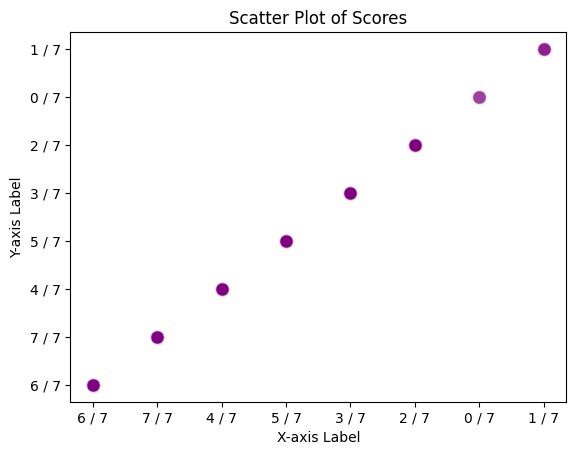

In [ ]:
#scatter plot
plt.scatter(df['Score'], df['Score'], alpha=0.5, color='purple', edgecolors='w', s=100, marker='o')
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Scatter Plot of Scores')
plt.show()

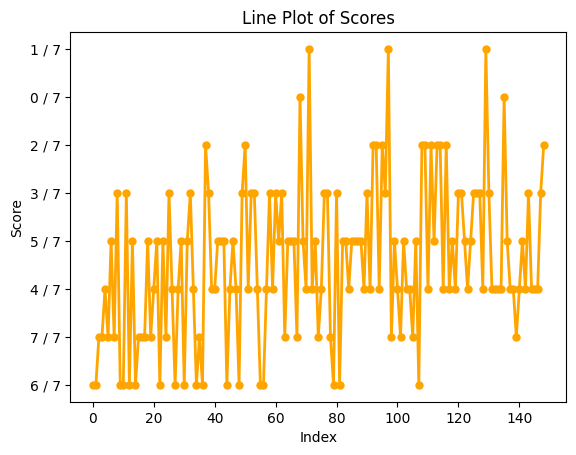

In [ ]:
#line plot
plt.plot(df.index, df['Score'], color='orange', marker='o', linestyle='-', linewidth=2, markersize=5)
plt.xlabel('Index')
plt.ylabel('Score')
plt.title('Line Plot of Scores')
plt.show()

#### B) Numerical vs Categorical

##### 🔸Non-Visual

In [13]:
# groupby Score vs count
score_grouped = df.groupby('Score').size()
score_grouped


Score
0 / 7     2
1 / 7     3
2 / 7    12
3 / 7    24
4 / 7    40
5 / 7    32
6 / 7    18
7 / 7    18
dtype: int64

In [16]:
#description statistics for Score vs count
df.groupby('Score').size().describe()

count     8.000000
mean     18.625000
std      13.255053
min       2.000000
25%       9.750000
50%      18.000000
75%      26.000000
max      40.000000
dtype: float64

##### 🔸Visual

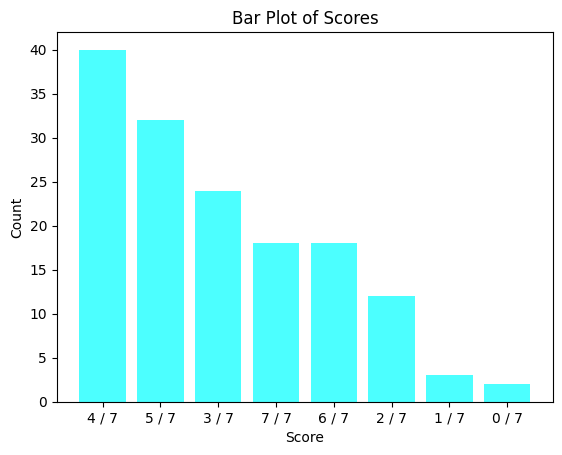

In [17]:
#barplot
plt.bar(df['Score'].value_counts().index, df['Score'].value_counts().values, color='cyan', alpha=0.7)
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Bar Plot of Scores')
plt.show()

#### C) Categorical vs Categorical

##### 🔸Non-Visual

In [18]:
# crosstab with tabulation
pd.crosstab(index=df['Score'], columns='count', margins=True)

col_0,count,All
Score,,
0 / 7,2,2
1 / 7,3,3
2 / 7,12,12
3 / 7,24,24
4 / 7,40,40
5 / 7,32,32
6 / 7,18,18
7 / 7,18,18
All,149,149


In [19]:
#contingency table
pd.crosstab(df['Score'], df['Score'], margins=True)


Score,0 / 7,1 / 7,2 / 7,3 / 7,4 / 7,5 / 7,6 / 7,7 / 7,All
Score,,,,,,,,,
0 / 7,2,0,0,0,0,0,0,0,2
1 / 7,0,3,0,0,0,0,0,0,3
2 / 7,0,0,12,0,0,0,0,0,12
3 / 7,0,0,0,24,0,0,0,0,24
4 / 7,0,0,0,0,40,0,0,0,40
5 / 7,0,0,0,0,0,32,0,0,32
6 / 7,0,0,0,0,0,0,18,0,18
7 / 7,0,0,0,0,0,0,0,18,18
All,2,3,12,24,40,32,18,18,149


##### 🔸Visual

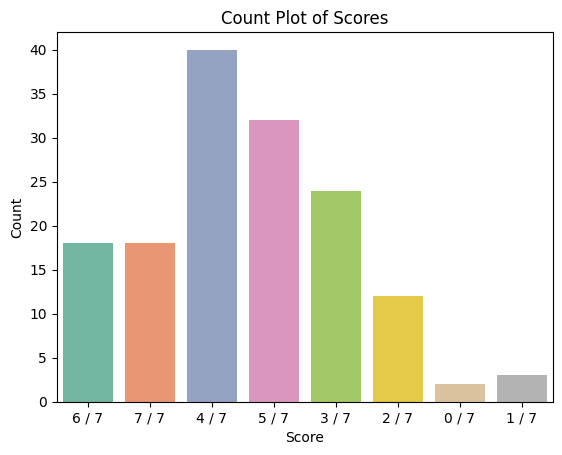

In [25]:
#countplot with seaborn
import seaborn as sns
sns.countplot(x='Score',hue='Score', data=df, palette='Set2')
plt.title('Count Plot of Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()